# Annotator model
---

In [1]:
import torch
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # Speed up convolutions

# Load the pre-trained Faster R-CNN and modify it for 2 classes (background, text)
annotation_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
num_classes = 2  # Background + Text
in_features = annotation_model.roi_heads.box_predictor.cls_score.in_features
annotation_model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

# Load the saved state dictionary and map it to the CPU
annotation_model.load_state_dict(torch.load('/kaggle/input/annotation_model/pytorch/default/3/annotation_model.pth', 
                                            map_location=torch.device('cpu')))

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:00<00:00, 168MB/s] 
<ipython-input-1-fc553f20d425>:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value

<All keys matched successfully>

In [2]:
import cv2
import torchvision.transforms as T
import matplotlib.pyplot as plt

def predict_and_visualize(model, image_path, device, threshold=0.5):
    """
    Runs object detection on an image and visualizes detected text regions.
    
    Args:
        model: Trained Faster R-CNN model
        image_path: Path to the image file
        device: 'cuda' or 'cpu'
        threshold: Confidence threshold for displaying bounding boxes
    """
    # Load image
    image = cv2.imread(image_path)
    
    orig_image = image.copy()
    
    # Transform image to tensor
    transform = T.Compose([T.ToTensor()])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Set model to evaluation mode
    model.eval()
    with torch.no_grad():
        prediction = model(image_tensor)
    
    # Extract boxes and scores
    boxes = prediction[0]['boxes'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()

    true_boxes = []
    for i, box in enumerate(boxes):
        if scores[i] > threshold:
            true_boxes.append(box)
    
    # Draw bounding boxes on the image
    for i, box in enumerate(true_boxes):
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(orig_image, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(orig_image, f"{scores[i]:.2f}", (x1, y1 - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    return image, sorted(true_boxes, key=lambda x: x[1]), orig_image

# OCR model
---

In [5]:
import torch.nn as nn

class HandwritingRecognitionModel(nn.Module):
    def __init__(self, num_characters):
        super(HandwritingRecognitionModel, self).__init__()
        
        self.cnn = nn.Sequential(
            # First CNN layer with larger kernel size
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.AvgPool2d(2,2),
            nn.Dropout2d(0.5),
            
            # Second CNN layer with larger kernel size
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AvgPool2d(2,2),
            nn.Dropout2d(0.5),
            
            # Third CNN layer
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            
            # Fourth CNN layer
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.5),

            # Fifth CNN layer
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )
        
        self.lstm_input_size = 512 * 12
        
        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=256,
            dropout=0.7,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )
        
        self.output = nn.Linear(512, num_characters)
    
    def forward(self, x):
        batch_size = x.size(0)
        
        x = x.permute(0, 3, 1, 2)
        
        #print("Shape before CNN:", x.shape)
        x = self.cnn(x)
        #print("Shape after CNN:", x.shape)
        
        x = x.permute(0, 3, 1, 2)
        #print("Shape after permute:", x.shape)
        
        x = x.reshape(batch_size, x.size(1), -1)
        #print("Shape after reshape:", x.shape)
        
        x, _ = self.lstm(x)
        
        x = self.output(x)
        return nn.functional.log_softmax(x, dim=2)

In [6]:
import torch
import pickle

with open('/kaggle/input/first_model/pytorch/default/5/num_to_char.pkl', 'rb') as f:
    num_to_char = pickle.load(f)

num_characters = len(num_to_char)

# Load the trained model
model_path = "/kaggle/input/first_model/pytorch/default/5/model.pth"  # Replace with your saved model path
model = torch.load(model_path, map_location=torch.device('cpu'))
model.eval()

<ipython-input-6-d2277fef1d20>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_path, map_location=torch.device('cpu'))


HandwritingRecognitionModel(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Dropout2d(p=0.5, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (9): Dropout2d(p=0.5, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): Dropout2d(p=0.5, inplace=False)
    (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

In [7]:
import torch
import cv2
import numpy as np

FIXED_HEIGHT = 45  # Ensure this matches training

def preprocess_crop(image, box):
    x1, y1, x2, y2 = map(int, box)
    crop = image[y1:y2, x1:x2]
    h = y2-y1
    w = x2-x1
    aspect_ratio = w / h if h != 0 else 1
    new_width = max(1, int(FIXED_HEIGHT * aspect_ratio))  # Avoid width=0
    resized = cv2.resize(crop, (new_width, FIXED_HEIGHT))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    normalized = gray.astype(np.float32) / 255.0
    normalized = np.expand_dims(normalized, axis=-1)  # (H, W, 1)
    
    return normalized


def collate_inference_images(image_tensors):
    widths = [img.shape[1] for img in image_tensors]
    max_width = max(widths)

    padded_images = []
    for img in image_tensors:
        pad_width = max_width - img.shape[1]
        padded = np.pad(img, ((0, 0), (0, pad_width), (0, 0)), mode='constant', constant_values=0)
        padded_images.append(padded)

    batch = np.stack(padded_images, axis=0)
    batch = np.transpose(batch, (0, 1, 2, 3))  # Expect (B, 1, H, W)
    print(batch.shape)
    return torch.tensor(batch, dtype=torch.float32)

def decode_predictions(preds, num_to_char):
    pred_indices = torch.argmax(preds, dim=2).detach().cpu().numpy()
    decoded = []
    for indices in pred_indices:
        prev_idx = None
        chars = []
        for idx in indices:
            if idx != prev_idx and idx != 0:  # 0 is <PAD>
                chars.append(num_to_char.get(idx, ''))
            prev_idx = idx
        decoded.append("".join(chars))
        
    return decoded

def run_inference(model, image, bboxes, num_to_char, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    image_tensors = [preprocess_crop(image, box) for box in bboxes]
    batch = collate_inference_images(image_tensors).to(device)
    batch = batch.contiguous()
    batch = batch.to(device)  # If you're using CUDA

    with torch.no_grad():
        preds = model(batch)  # Output shape: (B, T, C)
    decoded_strings = decode_predictions(preds, num_to_char)
    
    return decoded_strings


# Inference
---

In [8]:
def transcribe_handwriting(input, annotation_model, model, device, num_to_char, threshold=0.8):
    image, boxes, orig_image = predict_and_visualize(annotation_model, input, device, threshold=0.8)
    results = run_inference(model, image, boxes, num_to_char)
    return " ".join(results)

In [9]:
def detail_transcribe_handwriting(input, annotation_model, model, device, num_to_char, threshold=0.8):
    image, boxes, orig_image = predict_and_visualize(annotation_model, input, device, threshold=0.8)
    results = run_inference(model, image, boxes, num_to_char)
    plt.figure(figsize=(12, 8))
    plt.imshow(orig_image)
    plt.axis("off")
    plt.show()
    for i, prediction in enumerate(results):
        print(f"Prediction {i + 1}: {prediction}")
        x1, y1, x2, y2 = map(int, boxes[i])
        cropped_image = image[y1:y2, x1:x2]
        plt.imshow(cropped_image, cmap='gray')
        plt.show()

In [10]:
input = '/kaggle/input/complete-resized-journal-scans/resized_journal_scans/IMG_6242.JPG'

In [11]:
import time

start = time.time()
text = transcribe_handwriting(input, annotation_model, model, device, num_to_char, threshold=0.8)
print(text)
print('\nInference time:', round(time.time() - start, 2), 'seconds')

(30, 45, 930, 1)
Grateful p 02/08/ 23I Feel like I haven’t beeen very c grattul recently. So here we go: v My family is healtly and happy  I have friends that I can meetth and message. I am healthy, p young, strong, athletic, smart v and decent looking. I have  job that is well paid, easep comfortable sometimes, challenging and full ot opportunities to progres I am able to travel freely i and affordably. I am abld b to save money, invest freely, and make extra money passively t infinite  I have access dod entertainment and knowledge w at mys fingertips. I live in a time and a place wherev knowledge and hard work  reward appopristely. I do notiv ack food, shelter, or money, P Every day I work to get better  live more comfortably, therefore I focus on the next problem/obstacler in line. So, focusing on this can g get me down, but one should noti forget what one hasv

Inference time: 14.07 seconds


In [12]:
from textblob import TextBlob

replace_dict = {"  ": " ", "   ": " ", " t ":" ", " f ":" ", " b ":" ", " d ":" "}

# Loop through dictionary and replace
for old, new in replace_dict.items():
    text = text.replace(old, new)

# Create a TextBlob object
blob = TextBlob(text)

# Correct the spelling
corrected_text = blob.correct()

print(corrected_text)

Grateful p 02/08/ 23I Feel like I haven’t been very c grateful recently. To here we go: v By family is healthy and happy I have friends that I can meet and message. I am healthy, p young, strong, athletic, smart v and decent looking. I have job that is well paid, ease comfortable sometimes, challenging and full of opportunities to progress I am able to travel freely i and affordably. I am able to save money, invest freely, and make extra money passively infinite I have access did entertainment and knowledge w at my fingertips. I live in a time and a place where knowledge and hard work reward appropriately. I do not back food, shelter, or money, P Very day I work to get better live more comfortably, therefore I focus on the next problem/obstacle in line. To, rousing on this can g get me down, but one should not forget what one has


(30, 45, 930, 1)


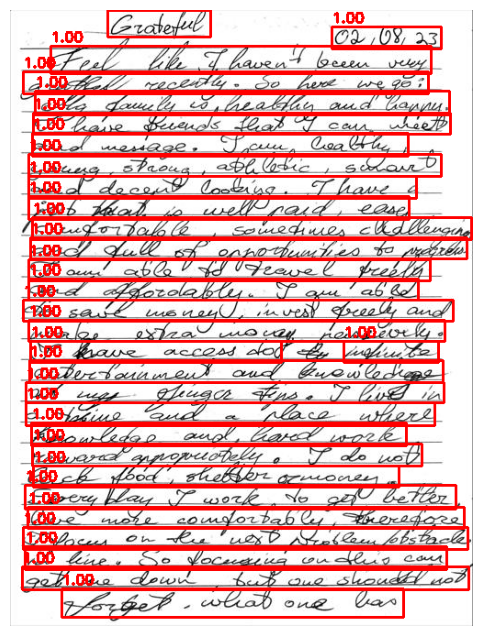

Prediction 1: Grateful p


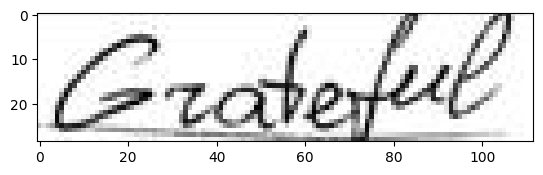

Prediction 2: 02/08/ 23I


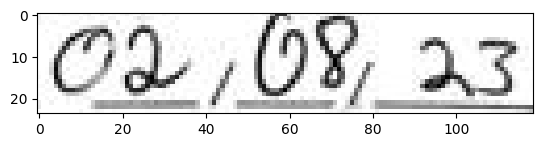

Prediction 3: Feel like I haven’t beeen very c


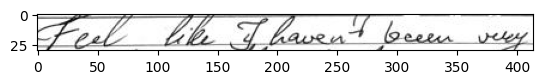

Prediction 4: grattul recently. So here we go: v


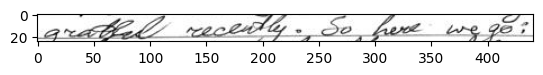

Prediction 5: My family is healtly and happy 


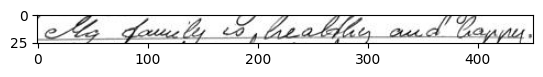

Prediction 6: I have friends that I can meetth


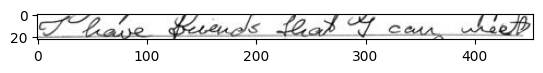

Prediction 7: and message. I am healthy, p


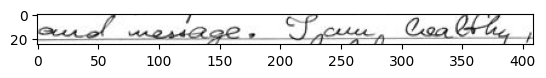

Prediction 8: young, strong, athletic, smart v


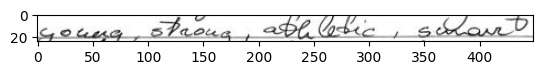

Prediction 9: and decent looking. I have 


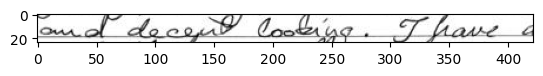

Prediction 10: job that is well paid, easep


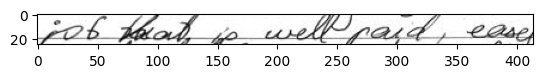

Prediction 11: comfortable sometimes, challenging


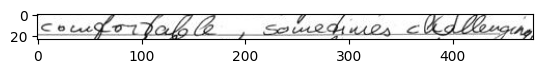

Prediction 12: and full ot opportunities to progres


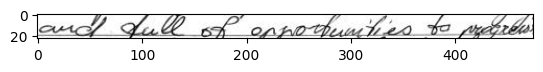

Prediction 13: I am able to travel freely i


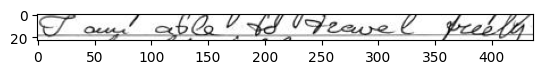

Prediction 14: and affordably. I am abld b


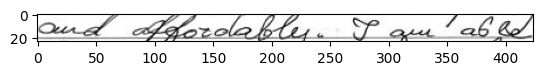

Prediction 15: to save money, invest freely, and


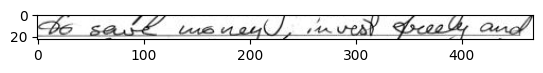

Prediction 16: make extra money passively t


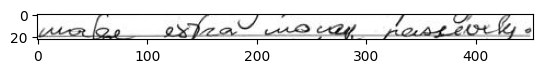

Prediction 17: infinite 


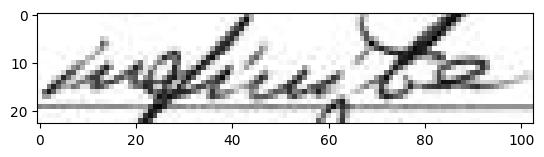

Prediction 18: I have access dod


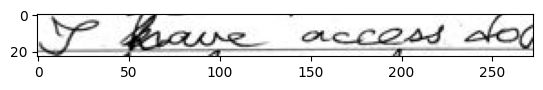

Prediction 19: entertainment and knowledge w


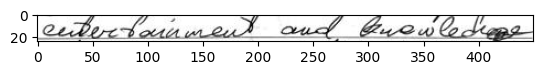

Prediction 20: at mys fingertips. I live in


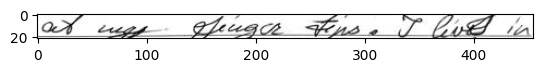

Prediction 21: a time and a place wherev


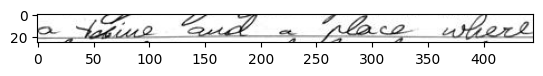

Prediction 22: knowledge and hard work 


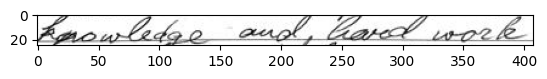

Prediction 23: reward appopristely. I do notiv


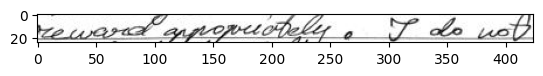

Prediction 24: ack food, shelter, or money, P


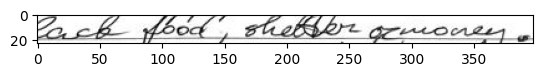

Prediction 25: Every day I work to get better 


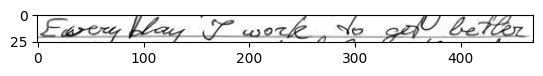

Prediction 26: live more comfortably, therefore


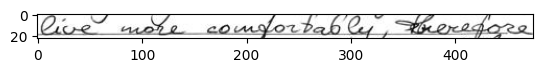

Prediction 27: I focus on the next problem/obstacler


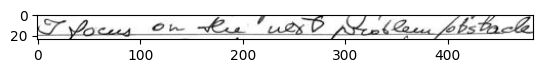

Prediction 28: in line. So, focusing on this can g


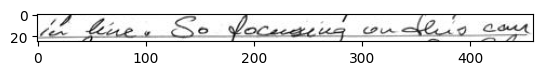

Prediction 29: get me down, but one should noti


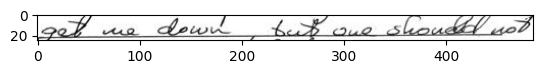

Prediction 30: forget what one hasv


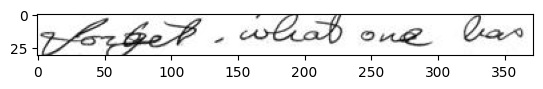

Grateful p 02/08/ 23I Feel like I haven’t beeen very c grattul recently. So here we go: v My family is healtly and happy I have friends that I can meetth and message. I am healthy, p young, strong, athletic, smart v and decent looking. I have job that is well paid, easep comfortable sometimes, challenging and full ot opportunities to progres I am able to travel freely i and affordably. I am abld to save money, invest freely, and make extra money passively infinite I have access dod entertainment and knowledge w at mys fingertips. I live in a time and a place wherev knowledge and hard work reward appopristely. I do notiv ack food, shelter, or money, P Every day I work to get better live more comfortably, therefore I focus on the next problem/obstacler in line. So, focusing on this can g get me down, but one should noti forget what one hasv

Inference time: 18.9 seconds


In [13]:
start = time.time()
detail_transcribe_handwriting(input, annotation_model, model, device, num_to_char, threshold=0.8)
print(text)
print('\nInference time:', round(time.time() - start, 2), 'seconds')